In [60]:
# import libraries for sentiment analysis
import pandas as pd
from pathlib import Path
import string
from collections import Counter
import matplotlib.pyplot as plt
# https://www.youtube.com/watch?v=lcgqP8g6i84&list=PLhTjy8cBISEoOtB5_nwykvB9wfEDscuEo&index=3

In [61]:
text_path = Path("training_data/djia_news.csv")
df = pd.read_csv(text_path, encoding="cp1252", low_memory=False,) 

print(df.head())

         Date  Label                                               Top1  \
0  2008-08-08      0  b"Georgia 'downs two Russian warplanes' as cou...   
1  2008-08-11      1  b'Why wont America and Nato help us? If they w...   
2  2008-08-12      0  b'Remember that adorable 9-year-old who sang a...   
3  2008-08-13      0  b' U.S. refuses Israel weapons to attack Iran:...   
4  2008-08-14      1  b'All the experts admit that we should legalis...   

                                                Top2  \
0            b'BREAKING: Musharraf to be impeached.'   
1        b'Bush puts foot down on Georgian conflict'   
2                 b"Russia 'ends Georgia operation'"   
3  b"When the president ordered to attack Tskhinv...   
4  b'War in South Osetia - 89 pictures made by a ...   

                                                Top3  \
0  b'Russia Today: Columns of troops roll into So...   
1  b"Jewish Georgian minister: Thanks to Israeli ...   
2  b'"If we had no sexual harassment we woul

In [62]:
# convert text to lower case 
lower_case_text = df['Top1'].str.lower()
print(lower_case_text.head())

0    b"georgia 'downs two russian warplanes' as cou...
1    b'why wont america and nato help us? if they w...
2    b'remember that adorable 9-year-old who sang a...
3    b' u.s. refuses israel weapons to attack iran:...
4    b'all the experts admit that we should legalis...
Name: Top1, dtype: object


In [63]:
# remove punctuation - converting string to string without prunctuations
cleaned_text = lower_case_text.str.translate(str.maketrans('', '', string.punctuation))
print(cleaned_text.head())

0    bgeorgia downs two russian warplanes as countr...
1    bwhy wont america and nato help us if they won...
2    bremember that adorable 9yearold who sang at t...
3    b us refuses israel weapons to attack iran report
4    ball the experts admit that we should legalise...
Name: Top1, dtype: object


## Tokenisation 

In [64]:
tokenise_words = cleaned_text.str.split() # get words sperated by space and store in a list
print(tokenise_words.head())

0    [bgeorgia, downs, two, russian, warplanes, as,...
1    [bwhy, wont, america, and, nato, help, us, if,...
2    [bremember, that, adorable, 9yearold, who, san...
3    [b, us, refuses, israel, weapons, to, attack, ...
4    [ball, the, experts, admit, that, we, should, ...
Name: Top1, dtype: object


In [65]:
# stop words - remove any words that dont add any value to the sentence - like : is, am, the , a , an , in , on , at , for.
stop_words = ["i","me","my","myself","we","our","ours","ourselves","you","your","yours","yourself","yourselves","he","him","his","himself","she","her",
              "hers","herself","it","its","itself","they","them","their","theirs","themselves","what","which","who","whom","this","that","these","those",
              "am","is","are","was","were","be","been","being","have","has","had","having","do","does","did","doing","a","an","the","and","but","if","or",
              "because","as","until","while","of","at","by","for","with","about","against","between","into","through","during","before","after","above",
              "below","to","from","up","down","in","out","on","off","over","under","again","further","then","once","here","there","when","where","why",
              "how","all","any","both","each","few","more","most","other","some","such","no","nor","not","only","own","same","so","than","too","very",
              "s","t","can","will","just","don","should","now"]

In [66]:
# final_words = []
# for word in tokenise_words:
#     # add words not in stop words to the list 
#     if word not in stop_words:
#         final_words.append(word) 

# print(final_words[:5])

stop_words_set = set(stop_words)
final_words = []
for token_list in tokenise_words:
    for w in token_list:
        w = w.strip()
        if w and w not in stop_words_set:
            final_words.append(w)

print(final_words[:50])

['bgeorgia', 'downs', 'two', 'russian', 'warplanes', 'countries', 'move', 'brink', 'war', 'bwhy', 'wont', 'america', 'nato', 'help', 'us', 'wont', 'help', 'us', 'help', 'iraq', 'bremember', 'adorable', '9yearold', 'sang', 'opening', 'ceremonies', 'fake', 'b', 'us', 'refuses', 'israel', 'weapons', 'attack', 'iran', 'report', 'ball', 'experts', 'admit', 'legalise', 'drugs', 'bmom', 'missing', 'gay', 'man', 'bad', 'hes', '21yearold', 'cheerleader', 'theyd', 'still']


In [67]:
# check if the word in the final wordes list is in the emotions list 

emotions_list = []
emotions_file = Path("training_data/emotions.txt")
with open(emotions_file,'r') as file:
    for line in file:
        clear_line = line.replace("\n",'').replace(",",'').replace("'",'').strip()
        word, emotion = clear_line.split(':')
        # print("Word:", word, "Emotion:", emotion)

        if word in final_words:
            emotions_list.append(emotion)

print("Emotions detected:", emotions_list)
w = Counter(emotions_list)
print(w)

Emotions detected: [' cheated', ' singled out', ' loved', ' angry', ' angry', ' attracted', ' independent', ' attached', ' cheated', ' powerless', ' fearless', ' happy', ' attracted', ' fearful', ' happy', ' average', ' attracted', ' powerless', ' hated', ' angry', ' sad', ' fearless', ' sad', ' belittled', ' demoralized', ' cheated', ' embarrassed', ' adequate', ' entitled', ' fearful', ' powerless', ' free', ' angry', ' singled out', ' happy', ' sad', ' sad', ' hated', ' entitled', ' happy', ' entitled', ' free', ' sad', ' attracted', ' attracted', ' singled out', ' alone', ' lost', ' attached', ' sad', ' happy', ' angry', ' attracted', ' codependent', ' obsessed', ' adequate', ' angry', ' safe', ' powerless', ' burdened', ' happy', ' hated', ' singled out', ' powerless', ' alone', ' free', ' hated', ' adequate', ' sad', ' fearful', ' sad', ' surprise', ' esteemed', ' independent', ' sad', ' surprise', ' anxious', ' codependent', ' anxious', ' fearful', ' fearful', ' sad', ' entitled

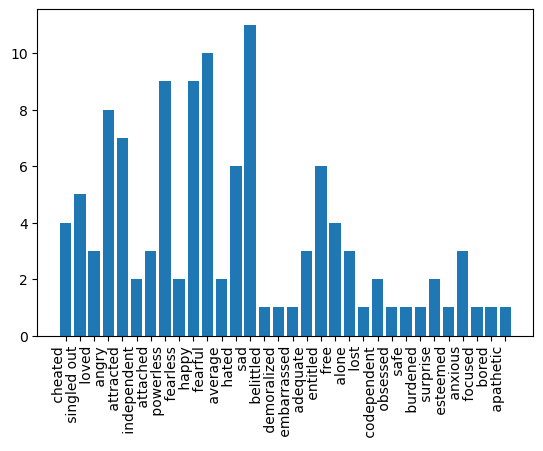

In [68]:
fig, axl = plt.subplots()
axl.bar(w.keys(), w.values())
fig.autofmt_xdate() # automatically update the axis to format all values 
plt.savefig('emotion_analysis.png')
plt.xticks(rotation=90)
plt.show()
